# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [34]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням

# TODO: тепер ще двічі без проміжних викликів set_seed()


Seed зафіксовано: 42


In [5]:
numbers = list(range(10))  # список для shuffle

# ДВІЧІ ДО set_seed()
print("=== ДО set_seed() ===")
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #1:", numbers)
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #2:", numbers)

set_seed()
print("\nSeed зафіксовано:", SEED)

# ДВІЧІ ПІСЛЯ set_seed() — з викликом ПЕРЕД КОЖНИМ
print("\n=== ПІСЛЯ set_seed() (з повторним викликом) ===")
set_seed()
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #1:", numbers)

set_seed()
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #2:", numbers)

# ДВІЧІ БЕЗ проміжного set_seed()
print("\n=== ПІСЛЯ set_seed() (без повторного виклику) ===")
set_seed()
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #1:", numbers)
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers); print("shuffle #2:", numbers)

=== ДО set_seed() ===
randint #1: 82
shuffle #1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
randint #2: 76
shuffle #2: [5, 8, 2, 1, 6, 3, 4, 0, 7, 9]

Seed зафіксовано: 42

=== ПІСЛЯ set_seed() (з повторним викликом) ===
randint #1: 82
shuffle #1: [0, 1, 2, 7, 3, 4, 9, 6, 5, 8]
randint #2: 82
shuffle #2: [6, 7, 2, 5, 4, 9, 8, 3, 0, 1]

=== ПІСЛЯ set_seed() (без повторного виклику) ===
randint #1: 82
shuffle #1: [3, 5, 2, 0, 9, 8, 1, 4, 6, 7]
randint #2: 76
shuffle #2: [9, 0, 2, 7, 8, 5, 4, 6, 3, 1]


## Пояснення до Вправи 1

До виклику `set_seed()` генератор випадкових чисел працює від початкового
стану (залежить від системного часу) — тому всі результати різні.

Після виклику `set_seed(42)` генератор скидається в детермінований стан.
Якщо викликати `set_seed()` **перед кожною** генерацією — отримуємо
**однакові** результати (той самий seed → та сама послідовність).

Якщо `set_seed()` викликати **один раз**, а потім генерувати кілька разів
поспіль — кожен наступний виклик дає **інше** число, бо генератор рухається
далі по послідовності, але вона **відтворювана** при повторному запуску
всього ноутбука.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [6]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [8]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [9]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape, zeros_arr.dtype)
print(sevens_arr, sevens_arr.shape, sevens_arr.dtype)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [10]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [11]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity, "ndim =", identity.ndim)
print(random_ints, "ndim =", random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] ndim = 2
[[6 3 7]
 [4 6 9]
 [2 6 7]] ndim = 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [12]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [13]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [14]:
df = pd.DataFrame({
    "name":  ["Оля", "Іван", "Марія", "Петро", "Аня", "Богдан"],
    "score": [78, 85, 92, 67, 95, 74],
})

top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


    name  score
4    Аня     95
2  Марія     92
1   Іван     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [16]:
df["grade"] = np.where(df["score"] >= 90, "A",
                np.where(df["score"] >= 75, "B", "C"))
print(df)


     name  score grade
0     Оля     78     B
1    Іван     85     B
2   Марія     92     A
3   Петро     67     C
4     Аня     95     A
5  Богдан     74     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [18]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)
print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t, sevens_t.shape, sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]]) torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [19]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)
print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [20]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)
print(from_list, from_list.shape, from_list.dtype, from_list.ndim)
print(random_t, random_t.shape, random_t.dtype, random_t.ndim)


tensor([[1, 2],
        [3, 4]]) torch.Size([2, 2]) torch.int64 2
tensor([[0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739]]) torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [21]:
n = 5.0
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("autograd:", x.grad.item())
print("analytic:", 2 * n)
assert abs(x.grad.item() - 2 * n) < 1e-6


autograd: 10.0
analytic: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [22]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

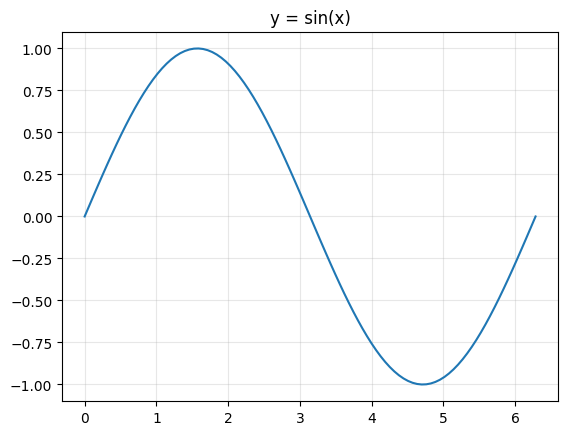

In [23]:
xs = np.linspace(0, 2 * np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.title("y = sin(x)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

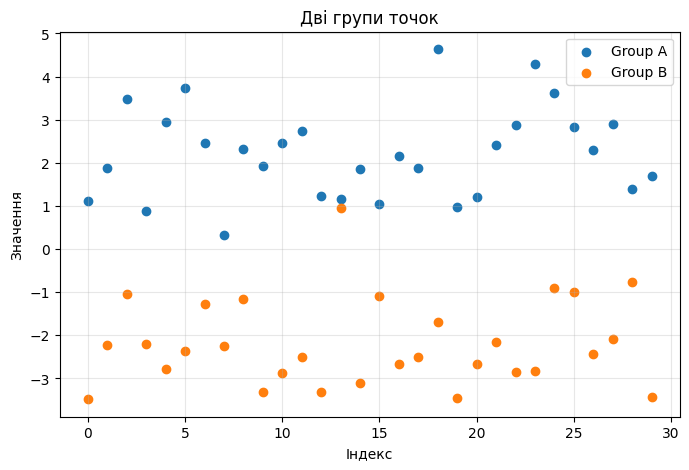

In [25]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.figure(figsize=(8, 5))
plt.scatter(range(30), group_a, color="C0", label="Group A")
plt.scatter(range(30), group_b, color="C1", label="Group B")
plt.legend()
plt.title("Дві групи точок")
plt.xlabel("Індекс")
plt.ylabel("Значення")
plt.grid(alpha=0.3)
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [26]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

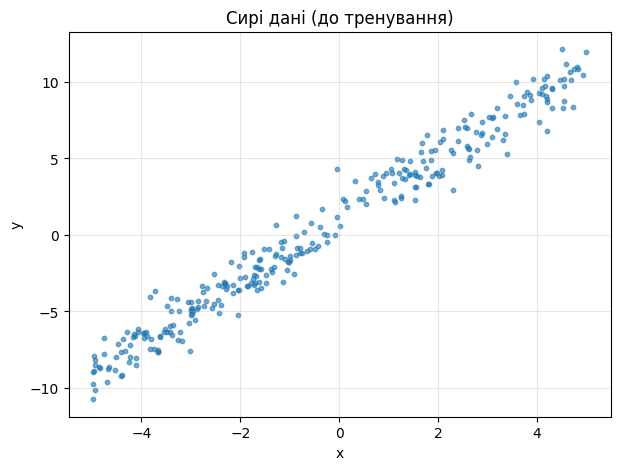

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(x1.numpy(), y1.numpy(), s=10, alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [28]:
perm = torch.randperm(TASK1_N)
x1_shuf = x1[perm]
y1_shuf = y1[perm]

n_train = int(0.7 * TASK1_N)
n_val   = int(0.15 * TASK1_N)

x_train1, y_train1 = x1_shuf[:n_train], y1_shuf[:n_train]
x_val1,   y_val1   = x1_shuf[n_train:n_train + n_val], y1_shuf[n_train:n_train + n_val]
x_test1,  y_test1  = x1_shuf[n_train + n_val:], y1_shuf[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [29]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=60.968754  w=1.7573 (true 2.0)  b=-0.2267 (true 1.0)
epoch   30  loss=1.037107  w=1.9979 (true 2.0)  b=0.9235 (true 1.0)
epoch   60  loss=1.033669  w=1.9997 (true 2.0)  b=0.9743 (true 1.0)
epoch   90  loss=1.033663  w=1.9998 (true 2.0)  b=0.9766 (true 1.0)
epoch   99  loss=1.033663  w=1.9998 (true 2.0)  b=0.9766 (true 1.0)


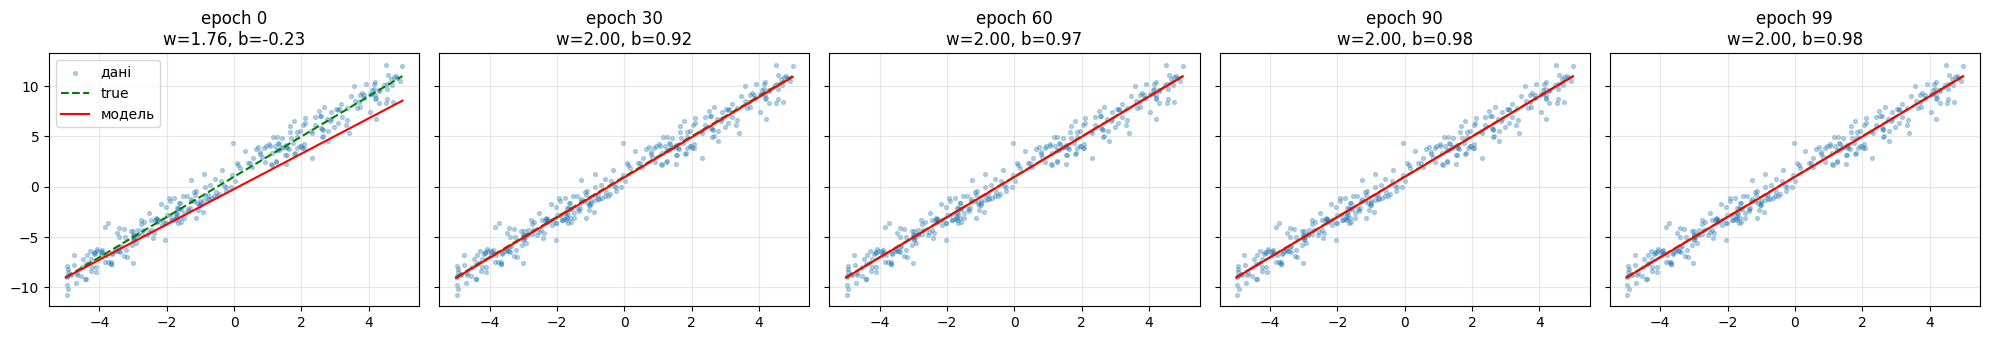

In [30]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

## Мій сценарій: години сну → продуктивність

Залежність: `productivity = 8 * hours_sleep + 20 + ε`

- `w = 8` — кожна додаткова година сну додає ~8 балів продуктивності.
- `b = 20` — базова продуктивність при 0 годин сну (умовна).
- Шум ε ~ N(0, 1.5) — бо в реальності на продуктивність впливають ще
  сотні факторів (кава, стрес, дедлайни).
- x у діапазоні [3, 10] годин — реальний діапазон сну дорослої людини.

CSV збережено:    hours_sleep  productivity
0     9.175885     92.571297
1     9.405027     93.787697
2     5.680046     66.747284
3     9.715139     97.577652
4     5.733138     66.470802
w = nan (true 8.0)
b = nan (true 20.0)
Val MSE: nan
Test MSE: nan


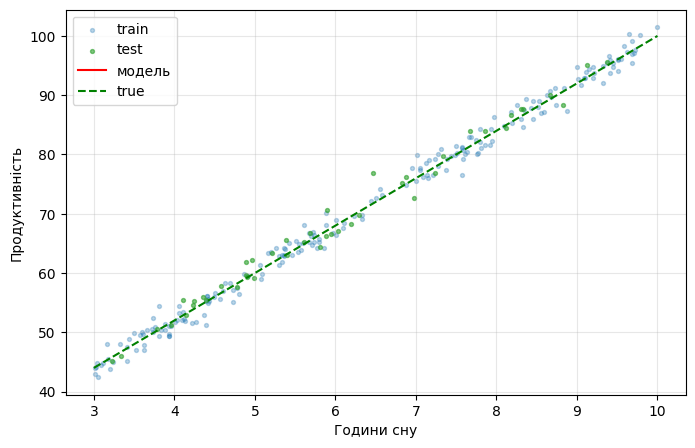

In [31]:
SCENARIO_W = 8.0
SCENARIO_B = 20.0
SCENARIO_N = 300

def generate_data(n, w, b, noise_std=1.5, seed=SEED):
    set_seed(seed)
    x = torch.empty(n, 1).uniform_(3, 10)
    y = w * x + b + noise_std * torch.randn(n, 1)
    return x, y

def save_csv(x, y, path):
    df = pd.DataFrame({"hours_sleep": x.squeeze().numpy(),
                       "productivity": y.squeeze().numpy()})
    df.to_csv(path, index=False)
    return df

def split_data(x, y, ratios=(0.7, 0.15, 0.15)):
    n = len(x)
    perm = torch.randperm(n)
    x, y = x[perm], y[perm]
    n_train = int(ratios[0] * n)
    n_val   = int(ratios[1] * n)
    return ((x[:n_train], y[:n_train]),
            (x[n_train:n_train+n_val], y[n_train:n_train+n_val]),
            (x[n_train+n_val:], y[n_train+n_val:]))

def train_linear(x_train, y_train, epochs=100, lr=0.05):
    model = torch.nn.Linear(1, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    history = []
    for ep in range(epochs):
        opt.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return model, history

def evaluate(model, x, y):
    with torch.no_grad():
        return torch.nn.functional.mse_loss(model(x), y).item()

# --- Виконання ---
x2, y2 = generate_data(SCENARIO_N, SCENARIO_W, SCENARIO_B)
df_saved = save_csv(x2, y2, os.path.join(ARTIFACT_DIR, "dataset.csv"))
print("CSV збережено:", df_saved.head())

(x_tr, y_tr), (x_v, y_v), (x_te, y_te) = split_data(x2, y2)
model2, hist = train_linear(x_tr, y_tr)

print(f"w = {model2.weight.item():.3f} (true {SCENARIO_W})")
print(f"b = {model2.bias.item():.3f} (true {SCENARIO_B})")
print("Val MSE:", evaluate(model2, x_v, y_v))
print("Test MSE:", evaluate(model2, x_te, y_te))

# Візуалізація
plt.figure(figsize=(8, 5))
plt.scatter(x_tr.numpy(), y_tr.numpy(), s=8, alpha=0.3, label="train")
plt.scatter(x_te.numpy(), y_te.numpy(), s=8, alpha=0.6, color="C2", label="test")
xs = torch.linspace(3, 10, 100).unsqueeze(1)
with torch.no_grad():
    plt.plot(xs.numpy(), model2(xs).numpy(), "r-", label="модель")
plt.plot(xs.numpy(), (SCENARIO_W * xs + SCENARIO_B).numpy(), "g--", label="true")
plt.xlabel("Години сну")
plt.ylabel("Продуктивність")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [32]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(model2.state_dict(), MODEL_PATH)
print("Модель збережено:", MODEL_PATH)

# Перевірка, що файл існує
print("Існує:", os.path.exists(MODEL_PATH))

Модель збережено: /content/drive/MyDrive/ai_systems/lab1/model.pt
Існує: True


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [33]:
!pip install -q gradio
import gradio as gr

loaded_model = torch.nn.Linear(1, 1)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

def predict(hours_sleep):
    with torch.no_grad():
        x = torch.tensor([[float(hours_sleep)]])
        return float(loaded_model(x).item())

demo = gr.Interface(
    fn=predict,
    inputs=gr.Slider(3, 10, step=0.1, label="Години сну"),
    outputs=gr.Number(label="Прогноз продуктивності"),
    title="Сон → Продуктивність",
)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d96e74bcd50b4846b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```